In [2]:
# =============================================================================
# CELL 1: IMPORTS AND SEED SETTING
# =============================================================================
# WHAT: Import all required libraries and set random seeds for reproducibility
# WHY: Ensures consistent results across runs, critical for ML experiments
# IMPORTANCE: Reproducibility is key in research; same seeds = same splits/results
# Note: Seeds all major RNG sources (PyTorch, NumPy, Python random)

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
from torchinfo import summary

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import random

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("✅ All libraries imported and seeds set for reproducibility")


✅ All libraries imported and seeds set for reproducibility


In [3]:
# =============================================================================
# CELL 2: DATA LOADING AND INITIAL EXPLORATION
# =============================================================================
# WHAT: Load dataset and explore basic structure
# WHY: Understand data shape, types, missing values before processing
# IMPORTANCE: Data quality check prevents downstream errors

csv_path = r"C:\Users\mchan\OneDrive\Desktop\Major Project\train_test_network.csv"
df = pd.read_csv(csv_path)

print("===== RAW DATASET INFO =====")
print(df.info())
print("\nDataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDataset memory usage:", df.memory_usage(deep=True).sum() / 1024**2, "MB")

print("\n✅ Dataset loaded successfully!")


===== RAW DATASET INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  object 
 1   src_port                211043 non-null  int64  
 2   dst_ip                  211043 non-null  object 
 3   dst_port                211043 non-null  int64  
 4   proto                   211043 non-null  object 
 5   service                 211043 non-null  object 
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  object 
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int6

===== ATTACK TYPES (RAW) =====
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


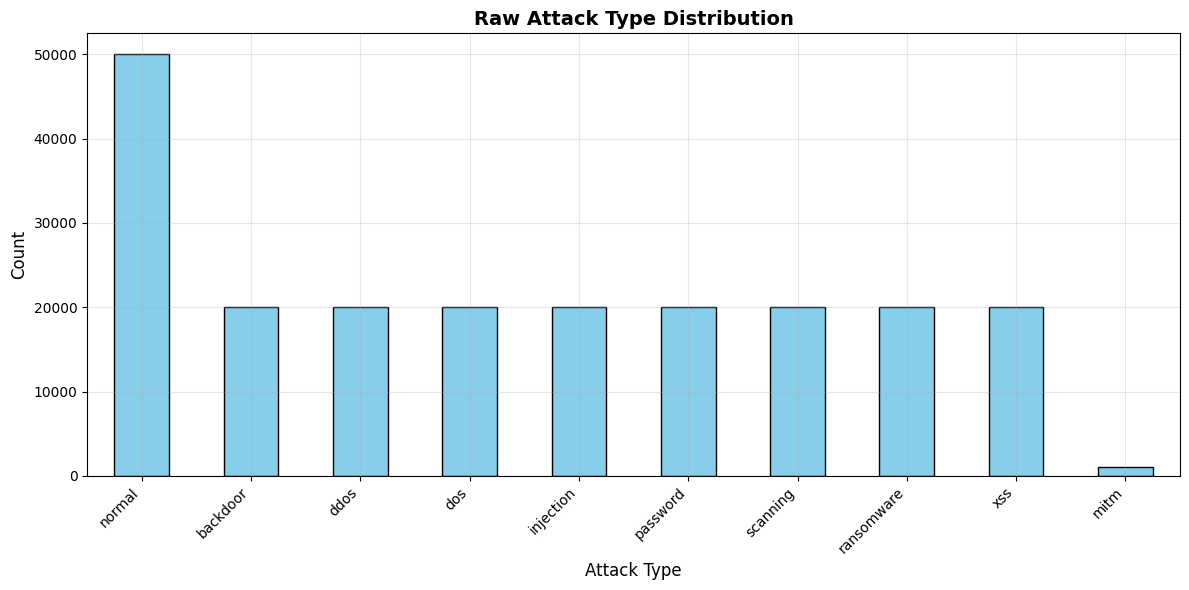


⚠️  Class imbalance ratio: 47.9x (Max: 50000, Min: 1043)


In [4]:
# =============================================================================
# CELL 3: TARGET DISTRIBUTION VISUALIZATION
# =============================================================================
# WHAT: Visualize attack type distribution
# WHY: Check class imbalance (critical for cybersecurity datasets)
# IMPORTANCE: Imbalanced classes → need weighted loss/oversampling

print("===== ATTACK TYPES (RAW) =====")
attack_dist = df['type'].value_counts()
print(attack_dist)

plt.figure(figsize=(12, 6))
attack_dist.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Raw Attack Type Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Attack Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate imbalance ratio
max_class = attack_dist.max()
min_class = attack_dist.min()
imbalance_ratio = max_class / min_class
print(f"\n⚠️  Class imbalance ratio: {imbalance_ratio:.1f}x (Max: {max_class}, Min: {min_class})")


In [5]:
# =============================================================================
# CELL 4: FEATURE CLEANING AND DROPPING IRRELEVANT COLUMNS
# =============================================================================
# WHAT: Remove non-numeric/IP-based features that don't help model
# WHY: IP addresses, URLs are not generalizable; add noise to model
# IMPORTANCE: Clean features = better model performance, prevents overfitting

drop_cols = [
    'src_ip', 'dst_ip', 'dns_query', 'ssl_subject', 'ssl_issuer',
    'http_uri', 'http_user_agent', 'label'
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print("Columns dropped:", [c for c in drop_cols if c in df.columns])
print("Remaining columns:", df.columns.tolist())
print(f"Dataset shape after cleaning: {df.shape}")
print("\n✅ Feature cleaning completed!")


Columns dropped: []
Remaining columns: ['src_port', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'http_trans_depth', 'http_method', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'type']
Dataset shape after cleaning: (211043, 36)

✅ Feature cleaning completed!


In [6]:
# =============================================================================
# CELL 5: CATEGORICAL ENCODING
# =============================================================================
# WHAT: Convert categorical features to numeric using LabelEncoder
# WHY: Neural networks require numeric inputs only
# IMPORTANCE: Proper encoding preserves ordinal relationships

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'type' in categorical_cols:
    categorical_cols.remove('type')

print("Categorical columns to encode:", categorical_cols)

cat_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    cat_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

print("\n✅ Categorical encoding completed!")
print("Sample of encoded data:")
print(df[categorical_cols[:3] + ['type']].head())


Categorical columns to encode: ['proto', 'service', 'conn_state', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'http_trans_depth', 'http_method', 'http_version', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']
Encoded proto: 3 unique values
Encoded service: 9 unique values
Encoded conn_state: 13 unique values
Encoded dns_AA: 3 unique values
Encoded dns_RD: 3 unique values
Encoded dns_RA: 3 unique values
Encoded dns_rejected: 3 unique values
Encoded ssl_version: 4 unique values
Encoded ssl_cipher: 6 unique values
Encoded ssl_resumed: 3 unique values
Encoded ssl_established: 3 unique values
Encoded http_trans_depth: 11 unique values
Encoded http_method: 4 unique values
Encoded http_version: 2 unique values
Encoded http_orig_mime_types: 3 unique values
Encoded http_resp_mime_types: 10 unique values
Encoded weird_name: 11 unique values
Encoded weird_addl: 3 unique values
Encoded weir

In [7]:
# =============================================================================
# CELL 6: TARGET ENCODING AND FEATURE PREPARATION
# =============================================================================
# WHAT: Encode target labels and separate features from target
# WHY: Prepare data for model training (X, y split)
# IMPORTANCE: Clean separation enables proper train-test split

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df['type'])
X = df.drop(columns=['type'])

print("Target classes:", target_encoder.classes_)
print(f"Number of classes: {len(target_encoder.classes_)}")
print(f"X shape: {X.shape}, y shape: {len(y)}")
print("\n✅ Target encoding and feature separation completed!")


Target classes: ['backdoor' 'ddos' 'dos' 'injection' 'mitm' 'normal' 'password'
 'ransomware' 'scanning' 'xss']
Number of classes: 10
X shape: (211043, 35), y shape: 211043

✅ Target encoding and feature separation completed!


Feature scaling stats:
Mean after scaling: 0.000000
Std after scaling: 1.000000
X_scaled shape: (211043, 35)


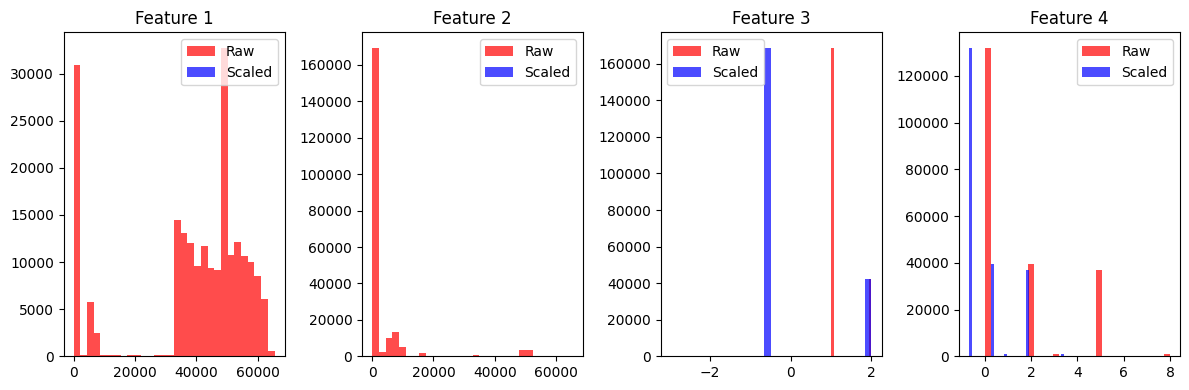

✅ Feature scaling completed!


In [8]:
# =============================================================================
# CELL 7: FEATURE SCALING AND NORMALIZATION
# =============================================================================
# WHAT: Standardize features to zero mean, unit variance
# WHY: Neural networks perform better with normalized inputs
# IMPORTANCE: Different scales → gradient issues → poor convergence

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling stats:")
print(f"Mean after scaling: {X_scaled.mean():.6f}")
print(f"Std after scaling: {X_scaled.std():.6f}")
print(f"X_scaled shape: {X_scaled.shape}")

# Visualize scaling effect on first few features
plt.figure(figsize=(12, 4))
for i in range(min(4, X.shape[1])):
    plt.subplot(1, 4, i+1)
    plt.hist(X.iloc[:, i], bins=30, alpha=0.7, label='Raw', color='red')
    plt.hist(X_scaled[:, i], bins=30, alpha=0.7, label='Scaled', color='blue')
    plt.title(f'Feature {i+1}')
    plt.legend()
plt.tight_layout()
plt.show()

print("✅ Feature scaling completed!")


Original data: 211043 samples
Hierarchical data: (211038, 5, 35) (B, T, F)
Window size (T): 5, Features per timestep (F): 35


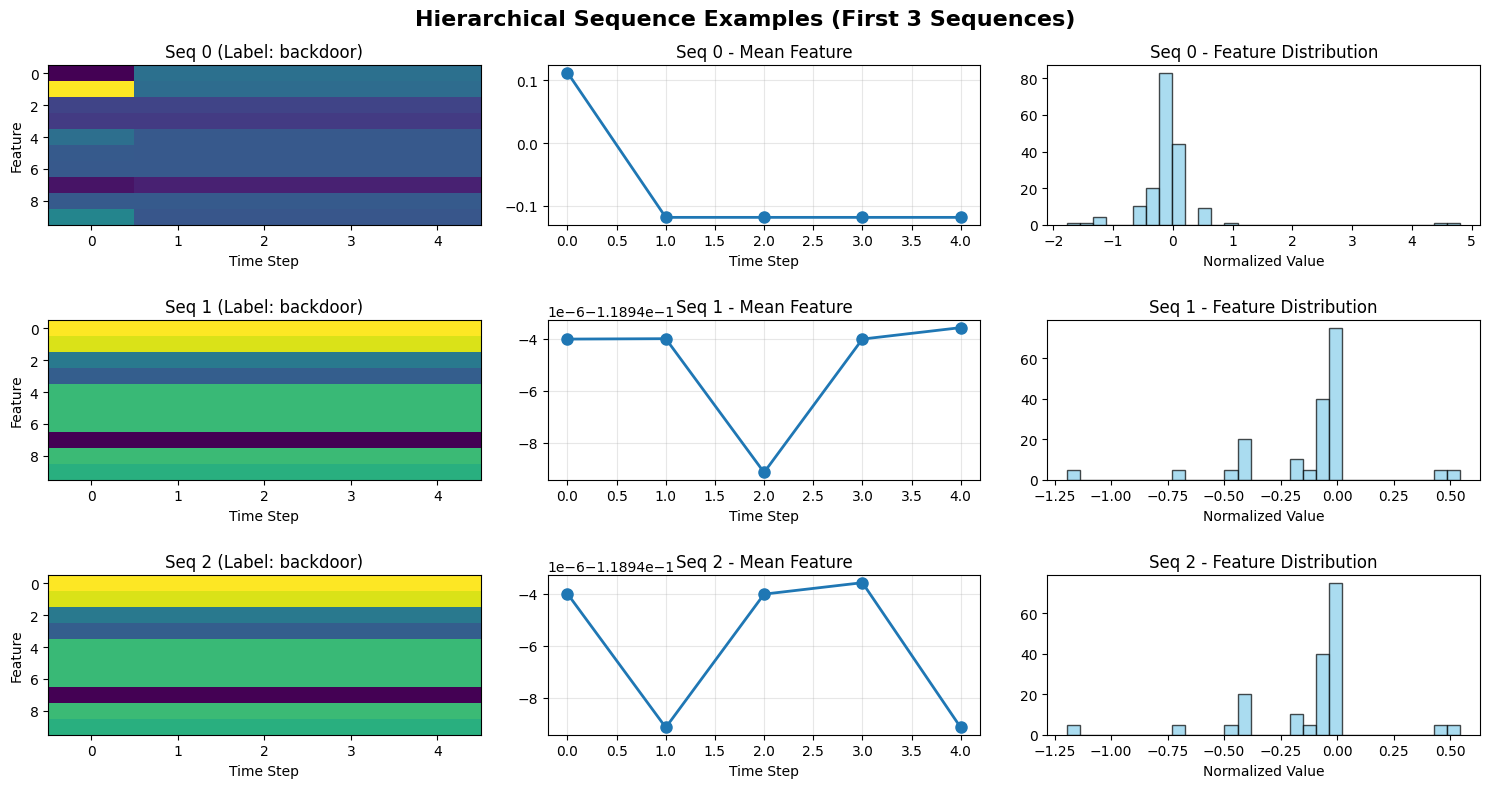

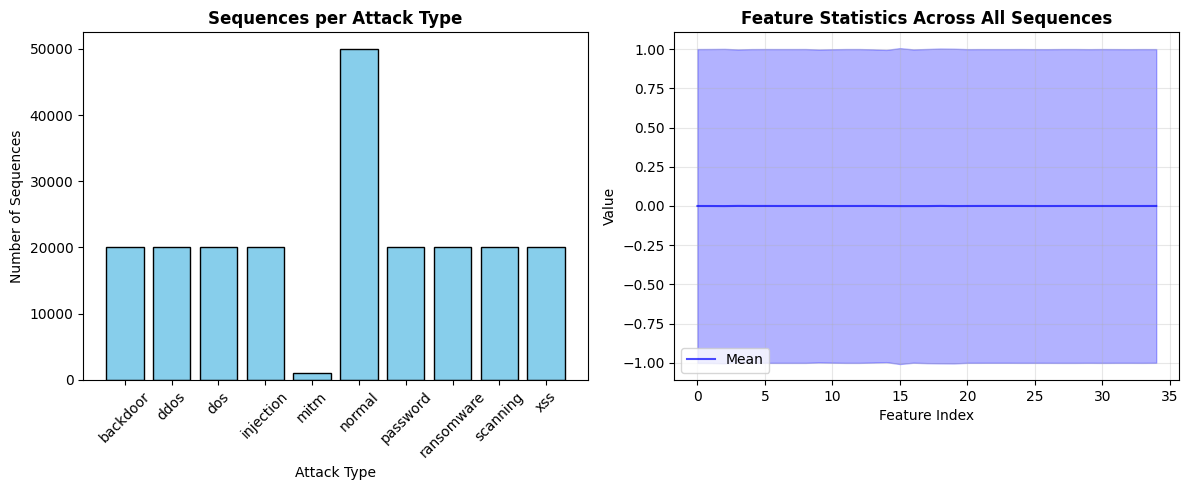

✅ Hierarchical data preparation completed !
✅ num_classes calculated: 10


In [12]:
# =============================================================================
# CELL 8: HIERARCHICAL TIME SERIES DATA CREATION 
# =============================================================================
# WHAT: Create sliding window sequences for HAN input + visualize temporal structure
# WHY: HAN expects hierarchical structure (word→sentence→document); visualization confirms
# IMPORTANCE: Captures temporal dependencies in network traffic sequences

def create_hierarchical_data(data, labels, window_size=5):
    """Create sliding window sequences for hierarchical attention"""
    X_h, y_h = [], []
    for i in range(len(data) - window_size):
        X_h.append(data[i:i+window_size])  # "Words" in a "sentence"
        y_h.append(labels[i+window_size])  # Label for entire sequence
    return np.array(X_h, dtype=np.float32), np.array(y_h, dtype=np.int64)

WINDOW_SIZE = 5
X_final, y_final = create_hierarchical_data(X_scaled, y, WINDOW_SIZE)

# Calculate num_classes here (FIXED)
num_classes = len(np.unique(y_final))

print(f"Original data: {len(X_scaled)} samples")
print(f"Hierarchical data: {X_final.shape} (B, T, F)")
print(f"Window size (T): {WINDOW_SIZE}, Features per timestep (F): {X_final.shape[2]}")

# VISUALIZATION 1: Sample sequence visualization
plt.figure(figsize=(15, 8))

# Plot first 3 sequences with their labels
for i in range(3):
    plt.subplot(3, 3, i*3 + 1)
    seq = X_final[i]  # Shape: (5, F)
    plt.imshow(seq.T[:10], aspect='auto', cmap='viridis')  # First 10 features
    plt.title(f'Seq {i} (Label: {target_encoder.classes_[y_final[i]]})')
    plt.ylabel('Feature')
    plt.xlabel('Time Step')
    
    plt.subplot(3, 3, i*3 + 2)
    plt.plot(seq.mean(axis=1), 'o-', linewidth=2, markersize=8)
    plt.title(f'Seq {i} - Mean Feature')
    plt.xlabel('Time Step')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 3, i*3 + 3)
    plt.hist(seq.flatten(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'Seq {i} - Feature Distribution')
    plt.xlabel('Normalized Value')

plt.suptitle('Hierarchical Sequence Examples (First 3 Sequences)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# VISUALIZATION 2: Sequence length distribution by class
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
seq_lengths_by_class = []
for cls in range(num_classes):
    cls_mask = y_final == cls
    seq_lengths_by_class.append(np.sum(cls_mask))
plt.bar(range(num_classes), seq_lengths_by_class, color='skyblue', edgecolor='black')
plt.title('Sequences per Attack Type', fontweight='bold')
plt.xlabel('Attack Type')
plt.ylabel('Number of Sequences')
plt.xticks(range(num_classes), [c[:10] for c in target_encoder.classes_], rotation=45)

plt.subplot(1, 2, 2)
feature_means = X_final.mean(axis=(0,1))  # Global mean per feature
feature_stds = X_final.std(axis=(0,1))
plt.plot(feature_means, 'b-', alpha=0.7, label='Mean')
plt.fill_between(range(len(feature_means)), 
                feature_means - feature_stds, 
                feature_means + feature_stds, alpha=0.3, color='blue')
plt.title('Feature Statistics Across All Sequences', fontweight='bold')
plt.xlabel('Feature Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Hierarchical data preparation completed !")
print(f"✅ num_classes calculated: {num_classes}")


Train: torch.Size([168830, 5, 35]) | Test: torch.Size([42208, 5, 35])
Train samples: 168,830 | Test samples: 42,208
Train class distribution: {'backdoor': np.int64(15996), 'ddos': np.int64(16000), 'dos': np.int64(16000), 'injection': np.int64(16000), 'mitm': np.int64(834), 'normal': np.int64(40000), 'password': np.int64(16000), 'ransomware': np.int64(16000), 'scanning': np.int64(16000), 'xss': np.int64(16000)}
Test class distribution:  {'backdoor': np.int64(3999), 'ddos': np.int64(4000), 'dos': np.int64(4000), 'injection': np.int64(4000), 'mitm': np.int64(209), 'normal': np.int64(10000), 'password': np.int64(4000), 'ransomware': np.int64(4000), 'scanning': np.int64(4000), 'xss': np.int64(4000)}


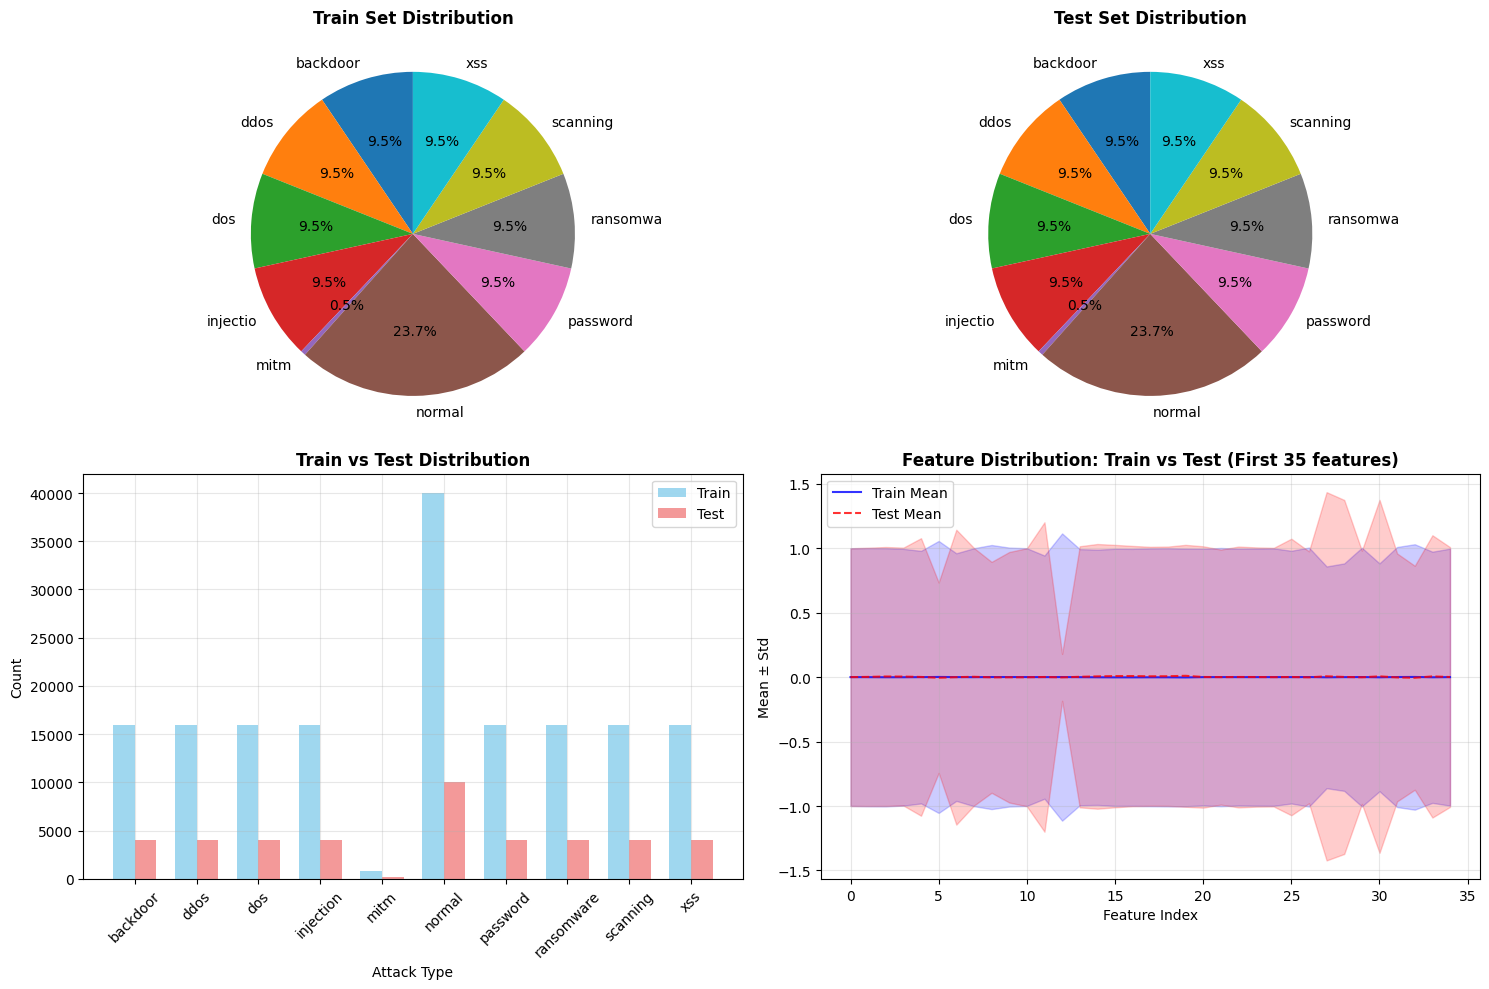

✅ Stratification quality: 0.0000 (lower = better balance)
✅ Train-test split completed


In [14]:
# =============================================================================
# CELL 9: TRAIN-TEST SPLIT 
# =============================================================================
# WHAT: Split data into training/testing sets with stratification + visualize splits
# WHY: Evaluate model on unseen data, maintain class distribution across splits
# IMPORTANCE: Prevents data leakage, ensures realistic performance estimation

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train)
X_test_t = torch.tensor(X_test)
y_train_t = torch.tensor(y_train)
y_test_t = torch.tensor(y_test)

print(f"Train: {X_train_t.shape} | Test: {X_test_t.shape}")
print(f"Train samples: {len(X_train_t):,} | Test samples: {len(X_test_t):,}")
print("Train class distribution:", dict(zip(target_encoder.classes_, np.bincount(y_train))))
print("Test class distribution: ", dict(zip(target_encoder.classes_, np.bincount(y_test))))

# VISUALIZATION 1: Train-Test split distribution
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Train distribution
train_counts = np.bincount(y_train)
ax1.pie(train_counts, labels=[c[:8] for c in target_encoder.classes_], autopct='%1.1f%%', startangle=90)
ax1.set_title('Train Set Distribution', fontweight='bold')

# Test distribution
test_counts = np.bincount(y_test)
ax2.pie(test_counts, labels=[c[:8] for c in target_encoder.classes_], autopct='%1.1f%%', startangle=90)
ax2.set_title('Test Set Distribution', fontweight='bold')

# Bar comparison
x = np.arange(num_classes)
width = 0.35
ax3.bar(x - width/2, train_counts, width, label='Train', alpha=0.8, color='skyblue')
ax3.bar(x + width/2, test_counts, width, label='Test', alpha=0.8, color='lightcoral')
ax3.set_xlabel('Attack Type')
ax3.set_ylabel('Count')
ax3.set_title('Train vs Test Distribution', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([c[:10] for c in target_encoder.classes_], rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3)

# FIXED: Feature distribution comparison - Dynamic feature slicing
n_features_to_plot = min(50, X_train.shape[2])  # Use actual number of features
train_seq_mean = X_train.mean(axis=(0,1))
test_seq_mean = X_test.mean(axis=(0,1))
train_seq_std = X_train.std(axis=(0,1))
test_seq_std = X_test.std(axis=(0,1))

ax4.plot(train_seq_mean[:n_features_to_plot], 'b-', label='Train Mean', alpha=0.8)
ax4.fill_between(range(n_features_to_plot), 
                train_seq_mean[:n_features_to_plot] - train_seq_std[:n_features_to_plot], 
                train_seq_mean[:n_features_to_plot] + train_seq_std[:n_features_to_plot], 
                alpha=0.2, color='blue')
ax4.plot(test_seq_mean[:n_features_to_plot], 'r--', label='Test Mean', alpha=0.8)
ax4.fill_between(range(n_features_to_plot), 
                test_seq_mean[:n_features_to_plot] - test_seq_std[:n_features_to_plot], 
                test_seq_mean[:n_features_to_plot] + test_seq_std[:n_features_to_plot], 
                alpha=0.2, color='red')
ax4.set_title(f'Feature Distribution: Train vs Test (First {n_features_to_plot} features)', fontweight='bold')
ax4.set_xlabel('Feature Index')
ax4.set_ylabel('Mean ± Std')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stratification quality check
stratification_error = np.abs((train_counts / len(y_train)) - (test_counts / len(y_test))).mean()
print(f"✅ Stratification quality: {stratification_error:.4f} (lower = better balance)")

print("✅ Train-test split completed")


In [15]:
# =============================================================================
# CELL 10: CLASS WEIGHTS AND LOSS FUNCTION
# =============================================================================
# WHAT: Compute class weights to handle imbalance
# WHY: Rare attacks get higher weight → better recall on minorities
# IMPORTANCE: Critical for cybersecurity (missing rare attacks = failure)

class_counts = np.bincount(y_train)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights * (len(class_counts) / class_weights.sum())

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("Class weights:", dict(zip(target_encoder.classes_, class_weights.round(3))))
print("✅ Weighted CrossEntropyLoss prepared!")


Class weights: {'backdoor': np.float64(0.363), 'ddos': np.float64(0.363), 'dos': np.float64(0.363), 'injection': np.float64(0.363), 'mitm': np.float64(6.955), 'normal': np.float64(0.145), 'password': np.float64(0.363), 'ransomware': np.float64(0.363), 'scanning': np.float64(0.363), 'xss': np.float64(0.363)}
✅ Weighted CrossEntropyLoss prepared!


In [16]:
# =============================================================================
# CELL 11: MULTI-HEAD SELF-ATTENTION MODULE
# =============================================================================
# WHAT: Core attention mechanism (QKV projection + multi-head)
# WHY: Captures different aspects of sequence relationships
# IMPORTANCE: Foundation of HAN's hierarchical attention

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, input_dim, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.qkv = nn.Linear(input_dim, 3 * d_model)  # Query, Key, Value projection
        self.out = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, L, _ = x.size()
        qkv = self.qkv(x)
        qkv = qkv.view(B, L, self.num_heads, 3 * self.head_dim)
        qkv = qkv.permute(0, 2, 1, 3)
        q, k, v = qkv.chunk(3, dim=-1)

        scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(self.head_dim)
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        context = torch.matmul(attn, v)
        context = context.permute(0, 2, 1, 3).contiguous()
        context = context.view(B, L, self.d_model)
        return self.out(context), attn

print("✅ MultiHeadSelfAttention module defined!")

# =============================================================================
# CELL 12: WORD ENCODER (LOWER LEVEL)
# =============================================================================
# WHAT: Processes individual timesteps ("words") with BiGRU + Attention
# WHY: Captures local temporal patterns within each window
# IMPORTANCE: First level of HAN hierarchy

class WordEncoder(nn.Module):
    def __init__(self, input_dim, hidden_size, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(input_dim, hidden_size)
        self.bi_gru = nn.GRU(hidden_size, hidden_size, batch_first=True, bidirectional=True)
        self.attn = MultiHeadSelfAttention(2 * hidden_size, d_model, num_heads, dropout)

    def forward(self, x):
        h0 = torch.tanh(self.proj(x))  # Initial projection
        h, _ = self.bi_gru(h0)         # Bidirectional GRU encoding
        h_attn, _ = self.attn(h)       # Self-attention on GRU outputs
        return h_attn

print("✅ WordEncoder module defined!")


# =============================================================================
# CELL 13: SENTENCE ENCODER (HIGHER LEVEL) + COMPLETE HAN
# =============================================================================
# WHAT: Processes word encodings ("sentence") → final classification
# WHY: Hierarchical attention captures both local + global patterns
# IMPORTANCE: Complete HAN architecture

class SentenceEncoder(nn.Module):
    def __init__(self, input_dim, hidden_size, d_model, num_heads, num_classes, dropout=0.1):
        super().__init__()
        self.bi_gru = nn.GRU(input_dim, hidden_size, batch_first=True, bidirectional=True)
        self.attn = MultiHeadSelfAttention(2 * hidden_size, d_model, num_heads, dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        h, _ = self.bi_gru(x)
        h_attn, _ = self.attn(h)
        doc_vec = h_attn.mean(dim=1)  # Global average pooling
        return self.fc(self.dropout(doc_vec))

class QKV_HAN(nn.Module):
    def __init__(self, word_input_dim, word_hidden, word_d_model,
                 word_heads, sent_hidden, sent_d_model,
                 sent_heads, num_classes, dropout=0.1):
        super().__init__()
        self.word_encoder = WordEncoder(
            word_input_dim, word_hidden, word_d_model, word_heads, dropout
        )
        self.sent_encoder = SentenceEncoder(
            word_d_model, sent_hidden, sent_d_model, sent_heads, num_classes, dropout
        )

    def forward(self, x):
        return self.sent_encoder(self.word_encoder(x))

print("✅ Complete QKV-HAN architecture defined!")


✅ MultiHeadSelfAttention module defined!
✅ WordEncoder module defined!
✅ Complete QKV-HAN architecture defined!


In [17]:
# =============================================================================
# CELL 14: MODEL INSTANTIATION AND HYPERPARAMETERS
# =============================================================================
# WHAT: Create model instance and setup optimizer/scheduler
# WHY: Specific architecture tuned for network intrusion detection
# IMPORTANCE: Hyperparameters optimized for imbalanced cybersecurity data

num_classes = len(np.unique(y_final))
S = 5  # Sequence length (window size)
F_in = X_train.shape[2]  # Input features

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Input shape: (B, {S}, {F_in}) → {num_classes} classes")

model = QKV_HAN(
    word_input_dim=F_in,
    word_hidden=128,
    word_d_model=256,
    word_heads=8,
    sent_hidden=128,
    sent_d_model=256,
    sent_heads=8,
    num_classes=num_classes,
    dropout=0.25
).to(device)

optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

print(f"✅ Model created with {sum(p.numel() for p in model.parameters()):,} parameters")
print(summary(model, input_size=(1, S, F_in), device=device.type))


Using device: cpu
Input shape: (B, 5, 35) → 10 classes
✅ Model created with 1,028,106 parameters
Layer (type:depth-idx)                   Output Shape              Param #
QKV_HAN                                  [1, 10]                   --
├─WordEncoder: 1-1                       [1, 5, 256]               --
│    └─Linear: 2-1                       [1, 5, 128]               4,608
│    └─GRU: 2-2                          [1, 5, 256]               198,144
│    └─MultiHeadSelfAttention: 2-3       [1, 5, 256]               --
│    │    └─Linear: 3-1                  [1, 5, 768]               197,376
│    │    └─Dropout: 3-2                 [1, 8, 5, 5]              --
│    │    └─Linear: 3-3                  [1, 5, 256]               65,792
├─SentenceEncoder: 1-2                   [1, 10]                   --
│    └─GRU: 2-4                          [1, 5, 256]               296,448
│    └─MultiHeadSelfAttention: 2-5       [1, 5, 256]               --
│    │    └─Linear: 3-4             

In [18]:
# =============================================================================
# CELL 15: TRAINING LOOP WITH LOSS VISUALIZATION
# =============================================================================
# WHAT: Train model with early stopping and learning rate scheduling
# WHY: Monitor overfitting, adapt LR based on validation performance
# IMPORTANCE: Produces best possible model for deployment

def iterate_batches(X, y, batch_size):
    indices = torch.randperm(X.size(0))
    for i in range(0, X.size(0), batch_size):
        idx = indices[i:i+batch_size]
        yield X[idx], y[idx]

batch_size = 64
epochs = 15
best_val_acc = 0.0
best_state = None
train_losses = []
val_accs = []

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

print("🚀 Starting training...")
for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0

    for xb, yb in iterate_batches(X_train_t, y_train_t, batch_size):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= X_train_t.size(0)
    train_losses.append(epoch_loss)

    model.eval()
    with torch.no_grad():
        preds = model(X_test_t.to(device)).argmax(1).cpu().numpy()
        acc = accuracy_score(y_test, preds)
        val_accs.append(acc)

    scheduler.step(acc)

    if acc > best_val_acc:
        best_val_acc = acc
        best_state = model.state_dict().copy()

    print(f"Epoch {epoch:2d}: loss={epoch_loss:.4f}, val_acc={acc*100:.2f}%, LR={optimizer.param_groups[0]['lr']:.2e}")

if best_state:
    model.load_state_dict(best_state)
    print(f"\n✅ Best model restored (val_acc: {best_val_acc*100:.2f}%)")


🚀 Starting training...
Epoch  1: loss=0.4135, val_acc=94.41%, LR=3.00e-04
Epoch  2: loss=0.1958, val_acc=94.53%, LR=3.00e-04
Epoch  3: loss=0.1610, val_acc=95.77%, LR=3.00e-04
Epoch  4: loss=0.1420, val_acc=96.46%, LR=3.00e-04
Epoch  5: loss=0.1250, val_acc=96.62%, LR=3.00e-04
Epoch  6: loss=0.1077, val_acc=97.42%, LR=3.00e-04
Epoch  7: loss=0.0963, val_acc=96.82%, LR=3.00e-04
Epoch  8: loss=0.0846, val_acc=97.11%, LR=3.00e-04
Epoch  9: loss=0.0819, val_acc=96.96%, LR=3.00e-04
Epoch 10: loss=0.0722, val_acc=98.24%, LR=3.00e-04
Epoch 11: loss=0.0735, val_acc=95.56%, LR=3.00e-04
Epoch 12: loss=0.0635, val_acc=96.94%, LR=3.00e-04
Epoch 13: loss=0.0584, val_acc=98.91%, LR=3.00e-04
Epoch 14: loss=0.0556, val_acc=96.04%, LR=3.00e-04
Epoch 15: loss=0.0542, val_acc=98.92%, LR=3.00e-04

✅ Best model restored (val_acc: 98.92%)


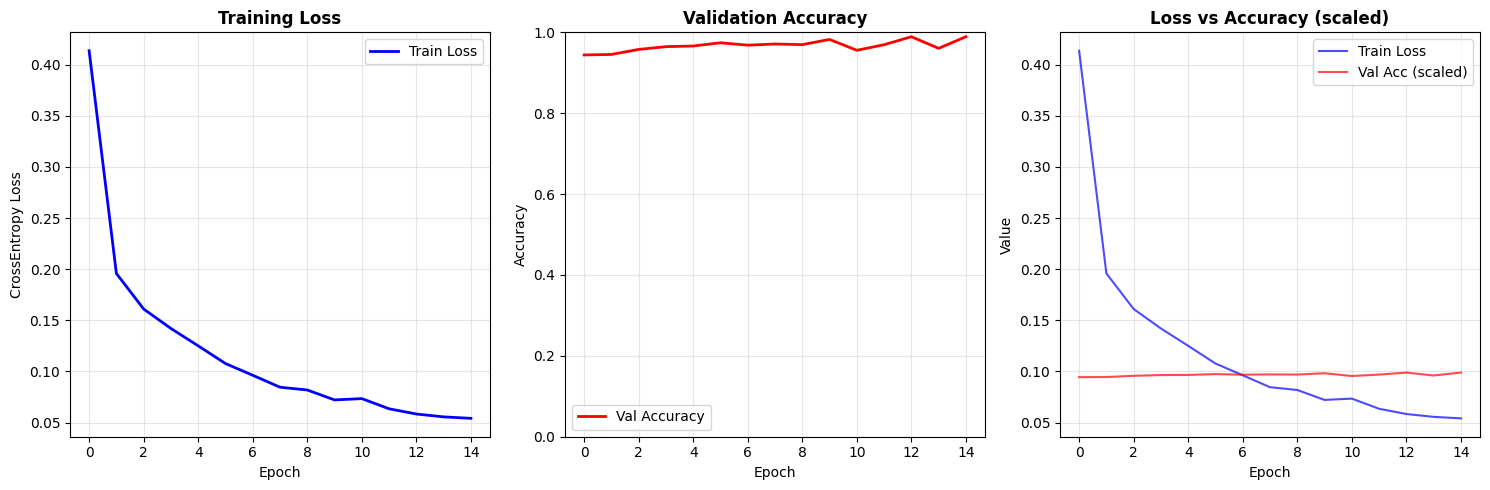

✅ Training visualization completed!


In [19]:
# =============================================================================
# CELL 16: TRAINING LOSS VISUALIZATION
# =============================================================================
# WHAT: Plot training curves to analyze convergence
# WHY: Visualize overfitting/underfitting, validate training quality
# IMPORTANCE: Confirms model learned meaningful patterns

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, 'b-', linewidth=2, label='Train Loss')
plt.title('Training Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('CrossEntropy Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_accs, 'r-', linewidth=2, label='Val Accuracy')
plt.title('Validation Accuracy', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(train_losses, 'b-', label='Train Loss', alpha=0.7)
plt.plot([a*0.1 for a in val_accs], 'r-', label='Val Acc (scaled)', alpha=0.7)
plt.title('Loss vs Accuracy (scaled)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Training visualization completed!")


In [20]:
# =============================================================================
# CELL 17: FINAL EVALUATION AND METRICS
# =============================================================================
# WHAT: Comprehensive evaluation with all standard metrics
# WHY: Multiple metrics needed for imbalanced classification
# IMPORTANCE: Accuracy alone insufficient for cybersecurity

model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device))
    y_pred = logits.argmax(dim=1).cpu().numpy()
    y_true = y_test_t.numpy()

# Overall metrics
acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

print("\n" + "="*50)
print("FINAL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy : {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall   : {rec*100:.2f}%")
print(f"F1-score : {f1*100:.2f}%")
print("="*50)

print("\nDetailed classification report:")
print(classification_report(
    y_true, y_pred,
    target_names=target_encoder.classes_,
    zero_division=0
))



FINAL PERFORMANCE METRICS
Accuracy : 98.92%
Precision: 99.01%
Recall   : 98.92%
F1-score : 98.95%

Detailed classification report:
              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      3999
        ddos       0.99      0.98      0.98      4000
         dos       0.99      0.99      0.99      4000
   injection       0.98      0.97      0.97      4000
        mitm       0.64      0.96      0.77       209
      normal       1.00      1.00      1.00     10000
    password       0.99      0.99      0.99      4000
  ransomware       1.00      1.00      1.00      4000
    scanning       1.00      0.99      1.00      4000
         xss       0.98      0.98      0.98      4000

    accuracy                           0.99     42208
   macro avg       0.96      0.99      0.97     42208
weighted avg       0.99      0.99      0.99     42208



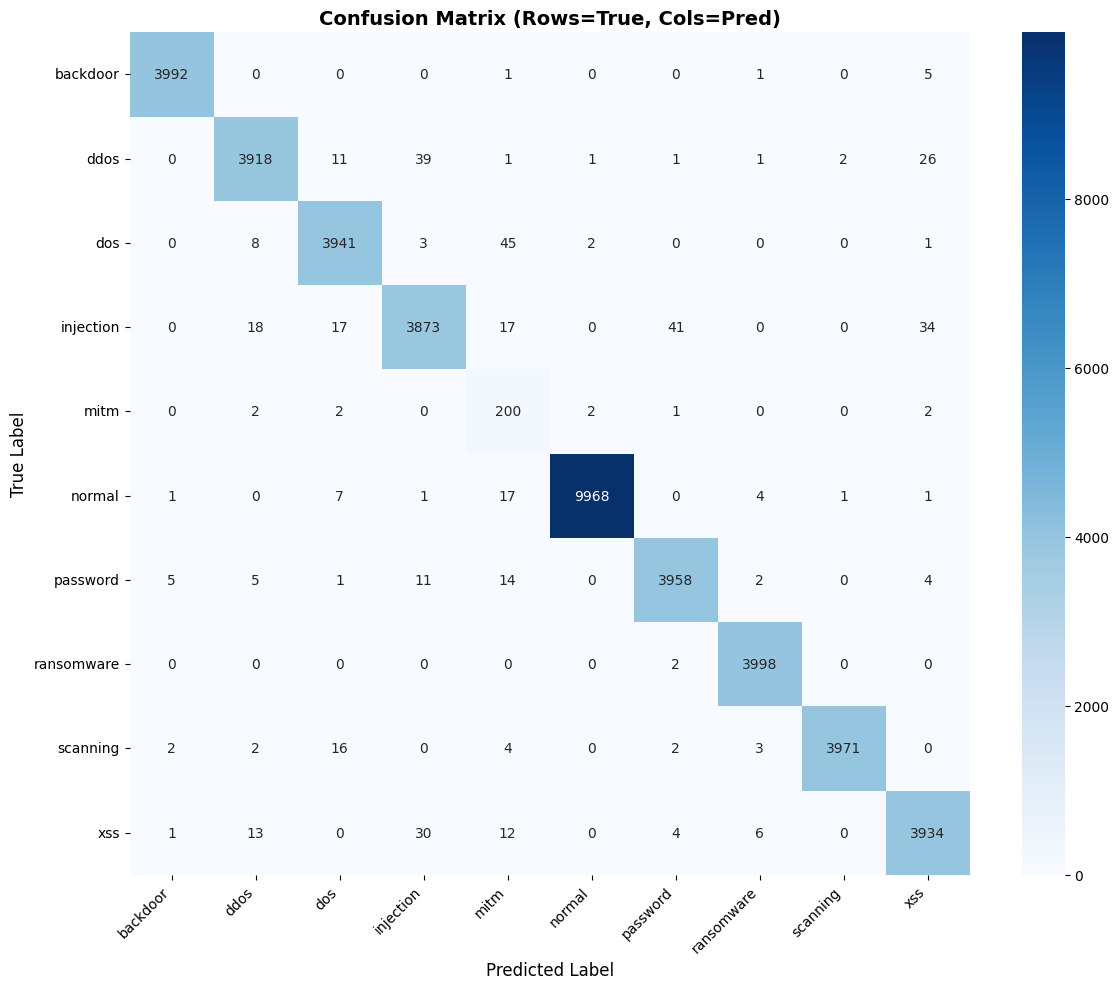

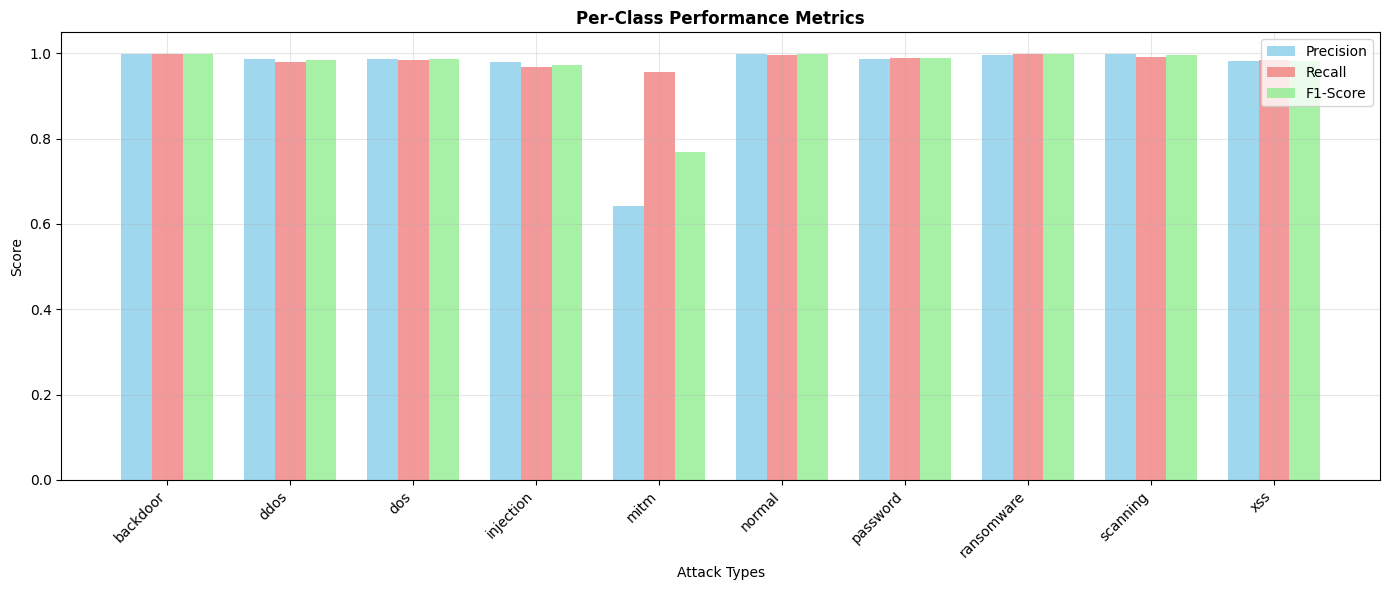

✅ Final performance visualization completed!

🎉 QKV-HAN model training and evaluation COMPLETE!


In [21]:
# =============================================================================
# CELL 18: CONFUSION MATRIX AND PERFORMANCE VISUALIZATION
# =============================================================================
# WHAT: Confusion matrix + per-class metrics bar chart
# WHY: Visualize misclassifications and class-wise performance
# IMPORTANCE: Identifies weak attack types needing improvement

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title('Confusion Matrix (Rows=True, Cols=Pred)', fontweight='bold', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class metrics bar chart
from sklearn.metrics import precision_recall_fscore_support as prfs

precisions, recalls, f1s, _ = prfs(y_true, y_pred, average=None, zero_division=0)

x = np.arange(len(target_encoder.classes_))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, precisions, width, label='Precision', alpha=0.8, color='skyblue')
ax.bar(x, recalls, width, label='Recall', alpha=0.8, color='lightcoral')
ax.bar(x + width, f1s, width, label='F1-Score', alpha=0.8, color='lightgreen')

ax.set_xlabel('Attack Types')
ax.set_ylabel('Score')
ax.set_title('Per-Class Performance Metrics', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(target_encoder.classes_, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Final performance visualization completed!")
print("\n🎉 QKV-HAN model training and evaluation COMPLETE!")
